In [1]:
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
def fillna(df):
    df['분야'].fillna('None')
    df['직원 수'].fillna(df['직원 수'].median(), inplace = True)
    df['고객수(백만명)'].fillna(df['고객수(백만명)'].median(), inplace= True)
    df['기업가치(백억원)'].fillna('0000').astype(str)
    return df 
def change(df):
    df['기업가치(백억원)'] = df['기업가치(백억원)'].str.extract(r'(\d{1,4})')[0].fillna('0').astype(int)
    return df
def drop(df):
    df.drop('ID', axis = 1, inplace = True)
    return df
def format_features(df):
    features = ['국가', '분야', '투자단계', '인수여부', '상장여부', '기업가치(백억원)']
    for feature in features:
        le = LabelEncoder()
        le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df


In [2]:
import pandas as pd
train= pd.read_csv('company_train.csv')
test = pd.read_csv('company_test.csv')

In [3]:
def transform_features(df):
    df = fillna(df)
    df = change(df)
    df = drop(df)
    df = format_features(df)
    return df


In [4]:
train =transform_features(train)
test = transform_features(test)

C:\Users\sjune\AppData\Local\Temp\ipykernel_6112\306107799.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['직원 수'].fillna(df['직원 수'].median(), inplace = True)
C:\Users\sjune\AppData\Local\Temp\ipykernel_6112\306107799.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [5]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler

def scaling(df):
    df['운영연수'] = 2025 - df['설립연도']
    scale_cols = [
        '운영연수',
        '직원 수',
        '고객수(백만명)',
        '총 투자금(억원)', 
        '연매출(억원)', 
        'SNS 팔로워 수(백만명)', 
        '기업가치(백억원)'
    ]
    scaler = StandardScaler()
    df[scale_cols] = scaler.fit_transform(df[scale_cols])
    df.drop('설립연도', axis = 1, inplace = True)
    return df
    
        
    

In [6]:
train = scaling(train)
test = scaling(test)

In [7]:
y = (train['성공확률']*10).astype(int)

In [8]:
y.head()

0    3
1    8
2    5
3    7
4    1
Name: 성공확률, dtype: int32

In [9]:
from sklearn.model_selection import train_test_split
X = train.drop('성공확률', axis = 1)
(X_train, X_val, y_train, y_val) = train_test_split(X, y, test_size = 0.2, random_state = 156)

In [10]:
X_test = test

In [11]:
#10개의 클래스 
#Random Forest Classifier
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(max_depth = 4, min_samples_split = 16, random_state = 156)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_split=16, random_state=156)

In [12]:
from sklearn.tree import export_graphviz

export_graphviz(dt_clf, out_file="tree.dot", feature_names= X_train.columns.tolist(), impurity = True, filled = True)

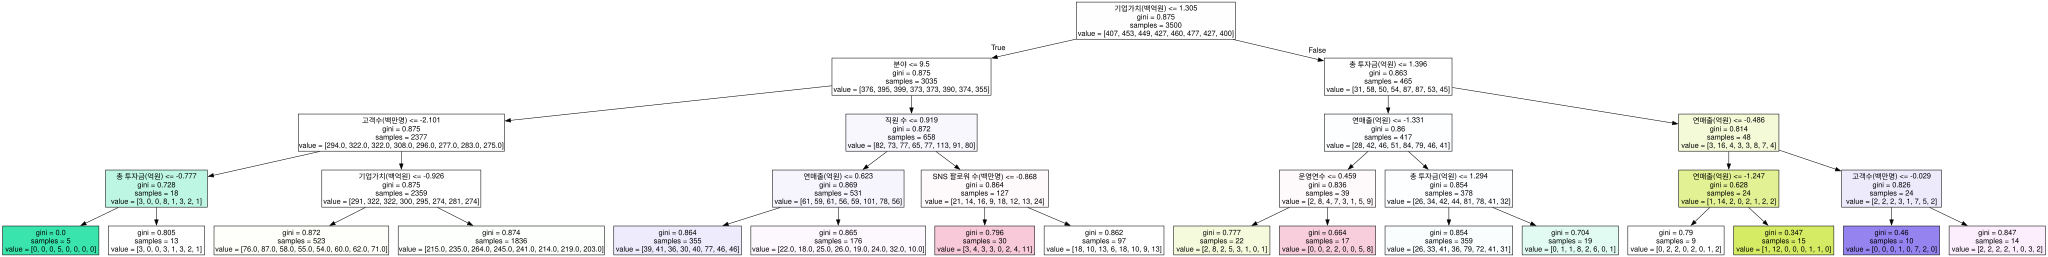

In [13]:
import  graphviz
with open("tree.dot",encoding='utf-8') as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score
def get_clf_eval(y_test, pred= None, pred_proba = None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred,average='macro')
    recall = recall_score(y_test, pred,average='macro')
    f1 = f1_score(y_test, pred,average='macro')
    roc_auc = roc_auc_score(y_test, pred_proba, average='macro',multi_class='ovr')
    
    print('오차행렬')
    print(confusion)
    print('정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율:{2:.4f} F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [15]:
pred = dt_clf.predict(X_val)
pred_proba = dt_clf.predict_proba(X_val)
get_clf_eval(y_val, pred, pred_proba)

오차행렬
[[ 1 12 47  1  6 12  3  1]
 [ 2 16 65  0 15 13 10  0]
 [ 3 12 67  1 10 12  6  1]
 [ 3 18 66  2 16 21  3  3]
 [ 7 17 68  0 14  9  4  0]
 [ 3 14 62  2 14 14  3  1]
 [ 3 13 61  1 16 18  8  1]
 [ 7 14 37  0  7  6  2  2]]
정확도:0.1416, 정밀도:0.1629, 재현율:0.1365 F1:0.1020, AUC:0.5248


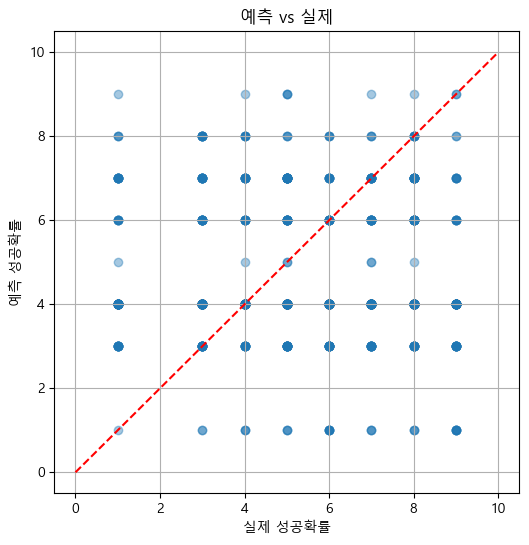

In [16]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로 찾기 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 또는 'NanumGothic', 'AppleGothic' (Mac)
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 부호 깨짐 방지
plt.figure(figsize=(6,6))
plt.scatter(y_val, pred, alpha=0.4)
plt.plot([0,10], [0,10], 'r--')  # 완벽한 예측선
plt.xlabel("실제 성공확률")
plt.ylabel("예측 성공확률")
plt.title("예측 vs 실제")
plt.grid(True)
plt.show()

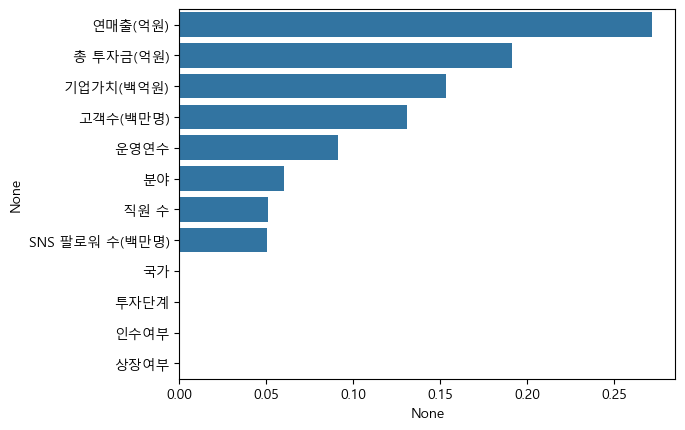

In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로 찾기 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 또는 'NanumGothic', 'AppleGothic' (Mac)
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 부호 깨짐 방지
import seaborn as sns 
import matplotlib.pyplot as plt
ftr_importance_values = dt_clf.feature_importances_
ftr_importances = pd.Series(ftr_importance_values, index = X_train.columns)

#중요도 순으로 Series 정렬 
ftr_top20 = ftr_importances.sort_values(ascending = False)[:20]
sns.barplot(x = ftr_top20, y = ftr_top20.index)
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=10, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)

In [19]:
pred_proba = rf.predict_proba(X_val)
get_clf_eval(y_val, pred, pred_proba)

오차행렬
[[ 1 12 47  1  6 12  3  1]
 [ 2 16 65  0 15 13 10  0]
 [ 3 12 67  1 10 12  6  1]
 [ 3 18 66  2 16 21  3  3]
 [ 7 17 68  0 14  9  4  0]
 [ 3 14 62  2 14 14  3  1]
 [ 3 13 61  1 16 18  8  1]
 [ 7 14 37  0  7  6  2  2]]
정확도:0.1416, 정밀도:0.1629, 재현율:0.1365 F1:0.1020, AUC:0.5355


In [21]:
sample_submission = pd.read_csv('sample_submission.csv')
final_predictions = rf.predict(X_test)/10
sample_submission['성공확률'] = final_predictions
sample_submission.to_csv('./rf_classifier_submission.csv', index = False, encoding = 'utf-8-sig')

In [49]:
##################################################################
import pandas as pd
train= pd.read_csv('company_train.csv')
test = pd.read_csv('company_test.csv')

train =transform_features(train)
test = transform_features(test)

train = scaling(train)
test = scaling(test)

y = (train['성공확률']*10).astype(int)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [50]:
from sklearn.model_selection import train_test_split
X = train.drop('성공확률', axis = 1)
(X_train, X_val, y_train, y_val) = train_test_split(X, y_encoded, test_size = 0.2, random_state = 156)

In [51]:
X_test = test

In [52]:
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_importance
import warnings 
warnings.filterwarnings('ignore')
print(X_train.shape, X_val.shape, X_test.shape)

(3500, 12) (876, 12) (1755, 12)


In [53]:
dtr = xgb.DMatrix(data = X_train, label = y_train)
dval = xgb.DMatrix(data = X_val, label = y_val)

In [54]:
from hyperopt import hp
xgb_search_space = {'max_depth':hp.quniform('max_depth',5,20,1),
                    'min_child_weight':hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate':hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree':hp.uniform('colsample_bytree', 0.5, 1),
                    'n_estimators':hp.quniform('n_estimators', 100, 500, 50),
                    'subsample':hp.uniform('subsample',0.5, 1.0),
                   }

In [55]:
import numpy as np
from hyperopt import fmin, tpe, Trials
trial_val = Trials()
best = fmin(fn = objective_func, 
            space = xgb_search_space, 
            algo = tpe.suggest, 
            max_evals = 50, 
            trials = trial_val, rstate = np.random.default_rng(seed = 9))
print('best:', best)

100%|██████████████████████████████████████████████| 50/50 [41:51<00:00, 50.22s/trial, best loss: -0.17771619282508352]
best: {'colsample_bytree': 0.7761930866442319, 'learning_rate': 0.03906966225360606, 'max_depth': 18.0, 'min_child_weight': 1.0, 'n_estimators': 500.0, 'subsample': 0.750267787703091}


In [57]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from hyperopt import STATUS_OK
def objective_func(search_space):
    xgb_model = XGBClassifier(max_depth = int(search_space['max_depth']),
                             min_child_weight = int(search_space['min_child_weight']),
                             learning_rate = search_space['learning_rate'],
                             colsample_bytree = search_space['colsample_bytree'],
                             n_estimators = int(search_space['n_estimators']),
                             subsample = search_space['subsample'],
                             eval_metric = 'mlogloss',
                             use_label_encoder=False
                             )
    scores = cross_val_score(xgb_model, X_train, y_train, scoring='accuracy', cv=3)
    return{'loss':-1*np.mean(scores), 'status': STATUS_OK}
    

In [59]:
dtr = xgb.DMatrix(data = X_train, label = y_train)
dval = xgb.DMatrix(data = X_val, label = y_val)

params = {'max_depth':int(best['max_depth']),
          'min_child_weight':int(best['min_child_weight']),
          'learning_rate':round(best['learning_rate'],5),
          'colsample_bytree':round(best['colsample_bytree'],5),
          'n_estimators':int(best['n_estimators']),
          'subsample':round(best['subsample'],5),
          'objective':'multi:softmax',
          'eval_metric':'mlogloss',
          'num_class': len(np.unique(y_train)) 
         }
num_rounds = 400
eval_list = [(dtr,'train'),(dval,'eval')]
xgb_model = xgb.train(params = params, dtrain = dtr, num_boost_round = num_rounds, early_stopping_rounds = 50, evals = eval_list)


[0]	train-mlogloss:2.04533	eval-mlogloss:2.07816
[1]	train-mlogloss:2.01128	eval-mlogloss:2.07666
[2]	train-mlogloss:1.97874	eval-mlogloss:2.07317
[3]	train-mlogloss:1.94674	eval-mlogloss:2.07017
[4]	train-mlogloss:1.91429	eval-mlogloss:2.06843
[5]	train-mlogloss:1.88248	eval-mlogloss:2.06752
[6]	train-mlogloss:1.85229	eval-mlogloss:2.06568
[7]	train-mlogloss:1.82236	eval-mlogloss:2.06457
[8]	train-mlogloss:1.79216	eval-mlogloss:2.06440
[9]	train-mlogloss:1.76285	eval-mlogloss:2.06352
[10]	train-mlogloss:1.73459	eval-mlogloss:2.06243
[11]	train-mlogloss:1.70713	eval-mlogloss:2.06136
[12]	train-mlogloss:1.67829	eval-mlogloss:2.06173
[13]	train-mlogloss:1.65048	eval-mlogloss:2.06175
[14]	train-mlogloss:1.62314	eval-mlogloss:2.06021
[15]	train-mlogloss:1.59697	eval-mlogloss:2.05940
[16]	train-mlogloss:1.57206	eval-mlogloss:2.05945
[17]	train-mlogloss:1.54688	eval-mlogloss:2.05974
[18]	train-mlogloss:1.52253	eval-mlogloss:2.05766
[19]	train-mlogloss:1.49846	eval-mlogloss:2.05709
[20]	train

In [64]:
sample_submission = pd.read_csv('sample_submission.csv')
dtest = xgb.DMatrix(X_test)
final_predictions = le.inverse_transform(xgb_model.predict(dtest).astype(int))/10

sample_submission['성공확률'] = final_predictions
sample_submission.to_csv('./XGBoost_classifier_submission.csv', index = False, encoding = 'utf-8-sig')


In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val, xgb_model.predict(dtest).astype(int), alpha=0.4)
plt.plot([0,1], [0,1], 'r--')  # 완벽한 예측선
plt.xlabel("실제 성공확률")
plt.ylabel("예측 성공확률")
plt.title("예측 vs 실제")
plt.grid(True)
plt.show()

ValueError: x and y must be the same size

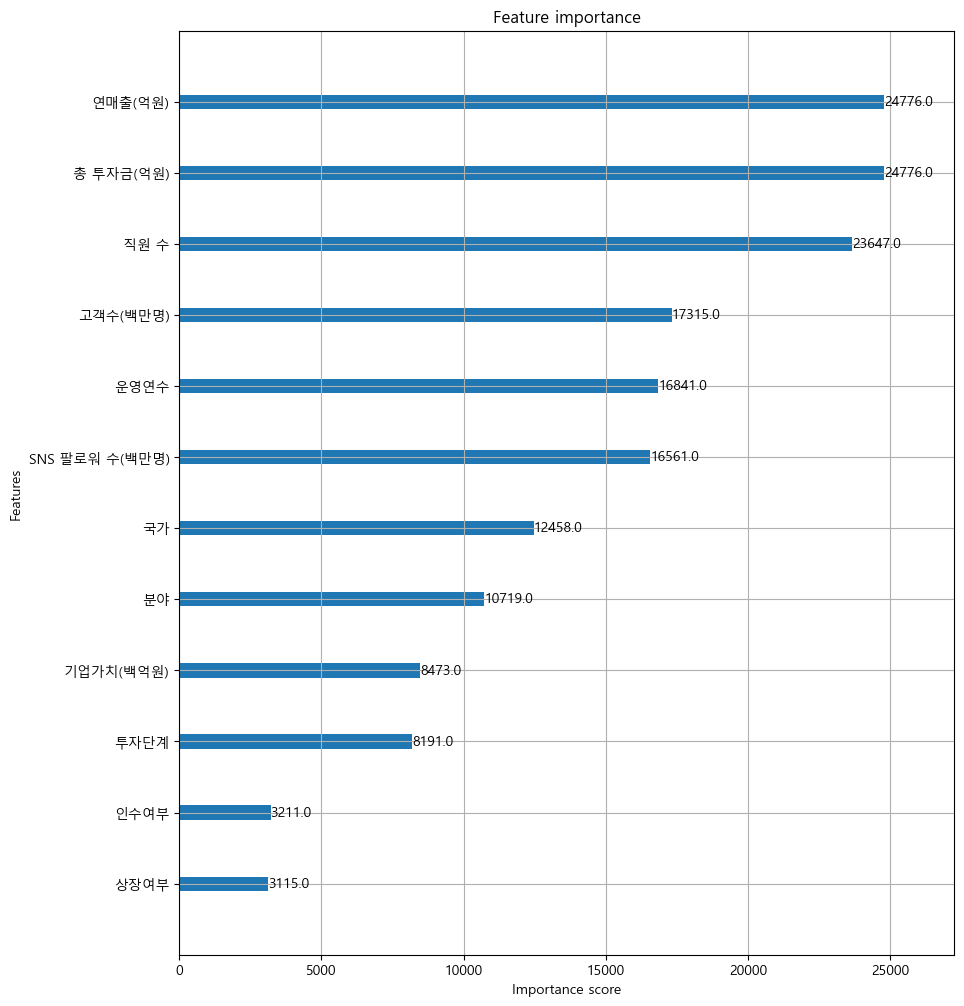

In [68]:
import matplotlib.pyplot as plt
%matplotlib inline 
fig, ax = plt.subplots(figsize = (10, 12))
plot_importance(xgb_model, ax = ax)
plt.show()